In [1]:
%%duckdb

create or replace table trips as
SELECT
    *, date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime,['%m/%d/%Y %H:%M','%m/%d/%Y %H:%M:%S','%Y-%m-%d %H:%M:%S']) as start_at,
    strptime(stoptime,['%m/%d/%Y %H:%M','%m/%d/%Y %H:%M:%S','%Y-%m-%d %H:%M:%S']) as stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
  using sample 200000 rows
)

,Count
0,200000


In [2]:
%%duckdb

select * from trips
limit 3;

,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,start_at,stop_at,duration_min
0,253,W 13 St & 5 Ave,40.735439,-73.994539,482,W 15 St & 7 Ave,40.739355,-73.999318,21178,Subscriber,1974.0,1,2015-11-13 17:46:02,2015-11-13 17:49:22,3
1,487,E 20 St & FDR Drive,40.733143,-73.975739,3141,1 Ave & E 68 St,40.765005,-73.958185,22235,Subscriber,1990.0,1,2016-11-23 22:14:30,2016-11-23 22:32:45,18
2,327,Vesey Pl & River Terrace,40.715338,-74.016584,383,Greenwich Ave & Charles St,40.735238,-74.000271,23884,Subscriber,1981.0,1,2015-12-28 12:48:01,2015-12-28 13:06:22,18


## Problem 1: Trip duration

### Part 1: Build a Regression Model

Build a regression to predict trip duration by using
- Day of time
- Distance between start and end stations (there might be more than one way to measure it)
- Hour of day
- Weekend indicator
- Don't forget to model bias (this one is intentionally not used in lecture)
- Also any thing you want to end

### Part 2: Experiment Design

- Ensure that you properly design your experiment to report unbiased performance metric you choose

### Part 3 [Optional]: Visualize

- Generate some fictional pickup and dropoff locations for bike trips (random pair selection)
- Estimate trip duration for those say 10 trips
- Visualize them on map using `pydeck` by using redish color for slower trips and greener for faster trips.

In [ ]:
#distance icin haversine (daha dogru) ve euclidean yaklasim sectim

In [3]:
%%duckdb -o df

select
    duration_min,
    extract(hour from start_at)                        as hour_of_day,
    isodow(start_at)                                   as day_of_week,
    case when isodow(start_at) in (6,7) then 1 else 0 end as weekend,
    st_distance_sphere(
        st_point("start station longitude", "start station latitude"),
        st_point("end station longitude",   "end station latitude")
    ) / 1000.0 as distance_sphere_km,
    sqrt(
        pow(("start station latitude"  - "end station latitude" ) * 111.0, 2) +
        pow(("start station longitude" - "end station longitude") *  85.0, 2)
    ) as distance_simple_km,
    1 as bias
from trips
where duration_min > 0 and duration_min < 120
  and "start station latitude" is not null
  and "end station latitude"   is not null
using sample 100000 rows

,duration_min,hour_of_day,day_of_week,weekend,distance_sphere_km,distance_simple_km,bias
0,6,15,5,0,1.159757,1.347208,1
1,25,20,3,0,3.614622,3.159435,1
2,6,22,3,0,1.854657,1.507277,1
3,12,21,6,1,2.329451,1.981668,1
4,7,11,2,0,0.340459,1.147732,1
...,...,...,...,...,...,...,...
99578,23,18,6,1,1.236011,1.435538,1
99579,13,16,1,0,0.697932,1.472819,1
99580,6,8,4,0,0.976866,1.404252,1
99581,6,9,4,0,0.806330,0.626901,1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def evaluate(feature_list, model=None):
    m = model or LinearRegression(fit_intercept=False)
    x_train, x_test, y_train, y_test = train_test_split(
        df[feature_list], df["duration_min"], test_size=0.2, random_state=42
    )
    m.fit(x_train, y_train)
    p = m.predict(x_test)
    return {
        "features": " + ".join(feature_list),
        "mae":  round(mean_absolute_error(y_test, p), 3),
        "rmse": round(np.sqrt(mean_squared_error(y_test, p)), 3),
        "r2":   round(r2_score(y_test, p), 4)
    }

In [ ]:
# distance karsilastirma + farkli feature kombinasyonlari
results = [
    evaluate(["distance_sphere_km", "bias"]),
    evaluate(["distance_simple_km", "bias"]),
    evaluate(["hour_of_day",        "bias"]),
    evaluate(["day_of_week",        "bias"]),
    evaluate(["weekend",            "bias"]),
    evaluate(["distance_sphere_km", "hour_of_day", "bias"]),
    evaluate(["distance_sphere_km", "hour_of_day", "day_of_week", "bias"]),
    evaluate(["distance_sphere_km", "hour_of_day", "day_of_week", "weekend", "bias"]),
    evaluate(["distance_simple_km", "hour_of_day", "day_of_week", "weekend", "bias"]),
    # Lasso denedim linear regden kotu
    evaluate(["distance_sphere_km", "hour_of_day", "day_of_week", "weekend", "bias"],
             Lasso(alpha=0.1, fit_intercept=False)),
]

pd.DataFrame(results).sort_values("r2", ascending=False)

In [ ]:
# final model
best_features = ["distance_sphere_km", "hour_of_day", "day_of_week", "weekend", "bias"]

x_train, x_test, y_train, y_test = train_test_split(
    df[best_features], df["duration_min"], test_size=0.2, random_state=42
)

model = LinearRegression(fit_intercept=False)
model.fit(x_train, y_train)
pred = model.predict(x_test)

print(f"MAE : {mean_absolute_error(y_test, pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred)):.3f}")
print(f"R2  : {r2_score(y_test, pred):.4f}")

print("\nCoefficients:")
for f, c in zip(best_features, model.coef_):
    label = "bias (intercept)" if f == "bias" else f
    print(f"  {label:<25}: {c:.4f}")

In [ ]:
result = x_test.copy()
result["actual"]    = y_test.values
result["predicted"] = pred.round(2)
result.head(10)

### Problem 2: Extending Naive Bayesian

### Part 1: Expand the NB Regression Idea to continous variable

$$
P(gender = a, speed_{bike} = x) = P(gender = a) P(speek_{bike} = x | gender = a)
$$

- Note that $P(speek_{bike} = x | gender = a)$ is  continous distribution.
- Expand the idea
- Build a predictive model for estimation biker gender using the bike speed ?

### Part 2: Use Visualization to decide best distribution 

- How should be $P(speek_{bike} = x | gender = a)$ modeled

In [7]:
%%duckdb -o gender_df

select gender, st_distance_sphere(
    st_point("start station longitude", "start station latitude"),
    st_point("end station longitude",   "end station latitude") ) / 1000.0 / duration_min as speed_km_per_min

from trips

where gender in (1, 2)
  and duration_min > 0 and duration_min < 120
  and "start station latitude" is not null
  and "end station latitude"   is not null

using sample 50000 rows

,gender,speed_km_per_min
0,1,0.104603
1,1,0.224514
2,2,0.032989
3,1,0.073701
4,1,0.089889
...,...,...
43631,1,0.127359
43632,1,0.028224
43633,1,0.040730
43634,1,0.125450


In [11]:
from sklearn.model_selection import train_test_split

# outlier atma
gender_df = gender_df[
    (gender_df["speed_km_per_min"] > 0.01) &
    (gender_df["speed_km_per_min"] < 0.5)
].copy()

print(gender_df["gender"].value_counts())

# FIX : train/test
train_df, test_df = train_test_split(gender_df, test_size=0.2, random_state=50)
train_df = train_df.copy()
test_df  = test_df.copy()

male   = train_df[train_df["gender"] == 1]["speed_km_per_min"]
female = train_df[train_df["gender"] == 2]["speed_km_per_min"]

gender
1    32606
2    10275
Name: count, dtype: int64


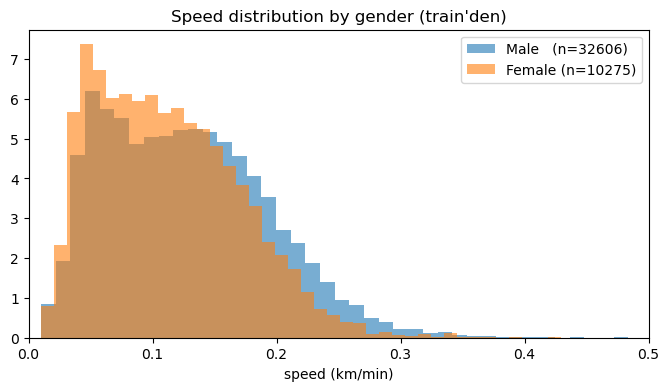

Male   — mean: 0.1274, std: 0.0653
Female — mean: 0.1120, std: 0.0577


In [12]:
import matplotlib.pyplot as plt

gender_df = gender_df[(gender_df["speed_km_per_min"] > 0) & (gender_df["speed_km_per_min"] < 1.0)].copy()

male   = gender_df[gender_df["gender"] == 1]["speed_km_per_min"]
female = gender_df[gender_df["gender"] == 2]["speed_km_per_min"]

plt.figure(figsize=(8, 4))
plt.hist(male,   bins=40, alpha=0.6, density=True, label=f"Male   (n={len(male)})")
plt.hist(female, bins=40, alpha=0.6, density=True, label=f"Female (n={len(female)})")
plt.xlabel("speed (km/min)")
plt.xlim(0, 0.5)
plt.title("Speed distribution by gender (train'den)")
plt.legend()
plt.show()

# dagilim normal, gausssian nb kullanacagiz
print(f"Male   — mean: {male.mean():.4f}, std: {male.std():.4f}")
print(f"Female — mean: {female.mean():.4f}, std: {female.std():.4f}")

#Sadece hiz ile gender ayirt etmek zor

In [22]:
from scipy.stats import norm
from sklearn.model_selection import train_test_split
import pandas as pd

# prior ve gaussian parametreler
train_df, test_df = train_test_split(gender_df, test_size=0.2, random_state=50)
n_train = len(train_df)

prior = {g: (train_df["gender"] == g).sum() / n_train for g in [1, 2]}
params = {g: {"mu": train_df[train_df["gender"] == g]["speed_km_per_min"].mean(),
              "sg": train_df[train_df["gender"] == g]["speed_km_per_min"].std()} for g in [1, 2]}

# ADD : bayes ile posterior prob. hesabi (train)
def predict_proba(speed):
    scores = {g: prior[g] * norm.pdf(speed, params[g]["mu"], params[g]["sg"]) for g in [1, 2]}
    total_score = sum(scores.values())
    return {g: scores[g] / total_score for g in [1, 2]}

def predict_gender(speed):
    probs = predict_proba(speed)
    return max(probs, key=probs.get)

sample_speeds = [0.05, 0.08, 0.10, 0.13, 0.15, 0.18, 0.20, 0.25, 0.30]

rows = []
for s in sample_speeds:
    p = predict_proba(s)
    rows.append({
        "speed (km/min)": s,
        "P(male|speed)": round(p[1], 4),
        "P(female|speed)": round(p[2], 4),
        "prediction": "male" if p[1] > p[2] else "female"
    })

print("posterior prob. w. bayes:")
display(pd.DataFrame(rows))

# test
test_df = test_df.copy()
test_df["pred"] = test_df["speed_km_per_min"].apply(predict_gender)

accuracy = (test_df["gender"] == test_df["pred"]).mean()
print(f"Manuel Gaussian NB accuracy: {accuracy:.4f}")

#  model prior'u da (male cok daha fazla) kullanarak makul accuracy veriyor

posterior prob. w. bayes:


,speed (km/min),P(male|speed),P(female|speed),prediction
0,0.05,0.7127,0.2873,male
1,0.08,0.7154,0.2846,male
2,0.10,0.7236,0.2764,male
3,0.13,0.7451,0.2549,male
4,0.15,0.7646,0.2354,male
5,0.18,0.7999,0.2001,male
6,0.20,0.8258,0.1742,male
7,0.25,0.8905,0.1095,male
8,0.30,0.9425,0.0575,male


Manuel Gaussian NB accuracy: 0.7653


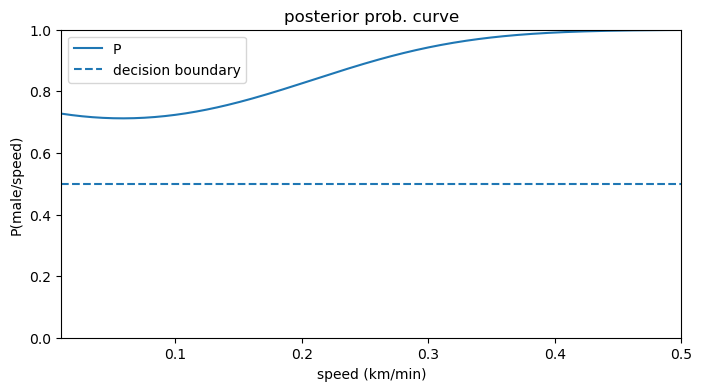

In [16]:
# ADD
import numpy as np
import matplotlib.pyplot as plt

speeds = np.linspace(0.01, 0.5, 300)
p_male = [predict_proba(s)[1] for s in speeds]

plt.figure(figsize=(8,4))
plt.plot(speeds, p_male, label="P")
plt.axhline(0.5, linestyle="--", label="decision boundary")
plt.xlabel("speed (km/min)")
plt.ylabel("P(male/speed)")
plt.title("posterior prob. curve")

plt.xlim(0.01, 0.5)
plt.ylim(0, 1)

plt.legend()
plt.show()

In [17]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# ADD : test
X_train = train_df[["speed_km_per_min"]]
y_train = train_df["gender"]
X_test  = test_df[["speed_km_per_min"]]
y_test  = test_df["gender"]
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

gnb = GaussianNB().fit(X_train, y_train)
print(f"gaussian accuracy: {accuracy_score(y_test, gnb.predict(X_test)):.4f}")

# confusion matrix
#pd.crosstab(y_test, gnb.predict(X_test), rownames=["actual"], colnames=["predicted"])
# manuelim ile sklearn sonucu esit


# ADD : predict prob
proba_df = pd.DataFrame(
    gnb.predict_proba(X_test[:8]),
    columns=["P(male)", "P(female)"]).round(4)

proba_df["speed"]      = X_test["speed_km_per_min"].values[:8].round(4)
proba_df["prediction"] = ["male" if r > 0.5 else "female" for r in proba_df["P(male)"]]
display(proba_df[["speed", "P(male)", "P(female)", "prediction"]])


test_speeds   = X_test["speed_km_per_min"].values[:8]
manuel_preds  = [max(predict_proba(s), key=predict_proba(s).get) for s in test_speeds]
n_preds = [int(x) for x in gnb.predict(X_test.iloc[:8])]

print(f"manuel : {manuel_preds}")
print(f"gaussiannb : {sklearn_preds}")

# olasilik buyuklugu ne kadar emin oldugumu gosteriyor
# P(male) >> P(female) olan ornekler guvenli tahmin, P ~ 0.5-0.6 olanlar belirsiz

gaussian accuracy: 0.7647


,speed,P(male),P(female),prediction
0,0.1325,0.7482,0.2518,male
1,0.1724,0.7905,0.2095,male
2,0.1034,0.7265,0.2735,male
3,0.0908,0.7201,0.2799,male
4,0.0623,0.7127,0.2873,male
5,0.0735,0.7144,0.2856,male
6,0.0607,0.7126,0.2874,male
7,0.0856,0.7180,0.2820,male


manuel : [1, 1, 1, 1, 1, 1, 1, 1]


NameError: name 'sklearn_preds' is not defined